In [60]:
import stixpy
from stixpy.product import Product
import numpy as np
import astropy
from astropy.io import fits
from astropy import units as u
# from stixdcpy.net import Request as jreq
from stixpy.coordinates.flare_location import stx_estimate_flare_location
from stixpy.calibration.flare_location import estimate_flare_location
from astropy.io import fits

from sunkit_spex.fitting.fitter import Fitter
from sunkit_spex.models.physical.thermal import ThermalEmission
from sunkit_spex.models.physical.nonthermal import ThickTarget
from sunkit_spex.models.physical.albedo import Albedo
from sunkit_spex.models.instrument_response import MatrixModel
from sunkit_spex.models.scaling import InverseSquareFluxScaling


from ndcube import NDMeta
from ndcube.extra_coords import QuantityTableCoordinate, TimeTableCoordinate
from astropy.coordinates import SpectralCoord
from astropy.time import Time
# from sunkit_spex.spectrum import Spectrum
from sunkit_spex.spectrum.spectrum import Spectrum, SpectralAxis
# from astropy.nddata import NDData, StdDevUncertainty
from sunkit_spex.spectrum.uncertainty import PoissonUncertainty

from sunpy.net import Fido, attrs as a

import os

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [62]:
instrument = a.Instrument.stix
product = a.stix.DataProduct.sci_xray_cpd	

download_dir = './data/'
os.makedirs(download_dir,exist_ok=True)

In [5]:
# Define search parameters
start_time = '2024-03-10T11:00:00'
end_time = '2024-03-10T13:00:00'
time = a.Time(start_time, end_time)

# Search + latest version
resp = Fido.search(instrument, time, product)
sci_table = resp['stix']
sci_table.filter_for_latest_version()
sci_table

2026-06-25 11:00:33 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-06-25 11:00:33 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
str23,str23,str4,str2,str3,str12,str3,int64
2024-03-10 10:58:52.000,2024-03-10 11:25:32.000,STIX,L1,SCI,sci-xray-cpd,V02,2403107510
2024-03-10 11:32:52.000,2024-03-10 11:38:47.000,STIX,L1,SCI,sci-xray-cpd,V02,2403109509
2024-03-10 11:56:26.000,2024-03-10 12:45:18.000,STIX,L1,SCI,sci-xray-cpd,V02,2403102193
2024-03-10 11:59:06.000,2024-03-10 12:15:40.000,STIX,L1,SCI,sci-xray-cpd,V02,2403109216
2024-03-10 12:43:15.000,2024-03-10 14:10:20.000,STIX,L1,SCI,sci-xray-cpd,V02,2403101620


In [6]:
# Select desired science file from the list and download using Fido.fetch

sci_file_download = Fido.fetch(sci_table[3], path=download_dir)

Files Downloaded: 100%|██████████| 1/1 [00:31<00:00, 31.91s/file]


In [7]:
# Define search parameters
start_time_bkg = '2024-03-08T18:00:00'
end_time_bkg = '2024-03-08T21:00:00'
time_bkg = a.Time(start_time_bkg, end_time_bkg)

# Search + latest version
resp_bkg = Fido.search(instrument, time_bkg, product)
bkg_table = resp_bkg['stix']
bkg_table.filter_for_latest_version()
bkg_table

2026-06-25 11:01:45 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-06-25 11:01:45 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
str23,str23,str4,str2,str3,str12,str3,int64
2024-03-08 18:31:47.000,2024-03-08 18:44:35.000,STIX,L1,SCI,sci-xray-cpd,V02,2403081100
2024-03-08 19:39:15.000,2024-03-08 20:32:35.000,STIX,L1,SCI,sci-xray-cpd,V02,2403087339


In [8]:
bkg_file_download = Fido.fetch(bkg_table[1], path=download_dir)

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  3.85file/s]


/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


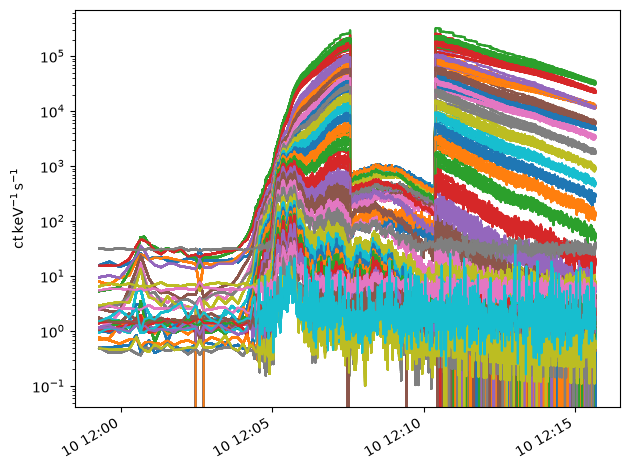

In [10]:
spec_prod = Product(sci_file_download[0])
spec_prod.plot_timeseries()

In [11]:
t_range = [spec_prod.meta['DATE-BEG'],Time(spec_prod.meta['DATE-END'])-15*u.min]
t_cent =  spec_prod.meta['DATE-AVG']

flare_location= stx_estimate_flare_location(sci_file_download[0], t_range)

flare_location_hpc = flare_location['hpc']
flare_location_stx = flare_location['stx']


print(flare_location_hpc)
print(flare_location_stx)

/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
2026-06-25 11:03:39 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-06-25 11:03:39 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  4.92file/s]
2026-06-25T11:03:39Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.68513718  85.98017198]] arcsec
2026-06-25 11:03:39 - stixpy.coordinates.transforms - INFO: Us

<SkyCoord (Helioprojective: obstime=2024-03-10T11:59:54.595, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T11:59:54.595, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (-17.19779844, -5.76247111, 8.38650795e+10)>): (Tx, Ty, distance) in (arcsec, arcsec, )
    (1342.04276689, -275.69950919, 1.)>
<SkyCoord (STIXImaging: obstime=2024-03-10T11:59:06.995, obstime_end=2024-03-10T12:00:42.195, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T11:59:54.595, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (-17.19779844, -5.76247111, 8.38650795e+10)>, rsun=695700.0 km): (Tx, Ty) in arcsec
    (-230.54783336, -1378.10520351)>


In [12]:
bkg = Product(bkg_file_download[0])

In [13]:
srm_dat = spec_prod.get_masked_srm(flare_location=flare_location)

edges =  [  5.   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  18.  20.
  22.  25.  28.  32.  36.  40.  45.  50.  56.  63.  70.  76.  84. 100.
 120. 150.  nan]
edges =  [  5.   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  18.  20.
  22.  25.  28.  32.  36.  40.  45.  50.  56.  63.  70.  76.  84. 100.
 120. 150.  nan]
edgeslow =  [  4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  18.
  20.  22.  25.  28.  32.  36.  40.  45.  50.  56.  63.  70.  76.  84.
 100. 120. 150.]
drm =  (3230, 3230)
drm_clipped_1 =  (3230, 3230)
drm_clipped =  (3230, 3230)
drm_new =  (3230, 30)


In [14]:
t_range = ["2024-03-10T12:05:55","2024-03-10T12:06:00"]

spectrum = spec_prod.get_spec_obj(event_time_range=t_range,
                             srm_dictionary=srm_dat,
                             bkg_data=bkg,
                             flare_location=flare_location)

/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


[ 0  1  2  3  4  5  6  7 13 14 15 19 20 21 22 23 24 25 26 27 28 29 30 31]
(24,)
[0 1 2 3 4 5 6 7]
(8,)


2026-06-25 11:03:55 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-06-25 11:03:55 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


var_shape_check =  (1325, 24, 8, 30)


Files Downloaded: 100%|██████████| 1/1 [00:00<00:00, 10.50file/s]
2026-06-25T11:03:55Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.68892162  85.92653947]] arcsec
2026-06-25 11:03:55 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.68892162  85.92653947]] arcsec


ct_de =  (30,)
cts_axis =  (31,)


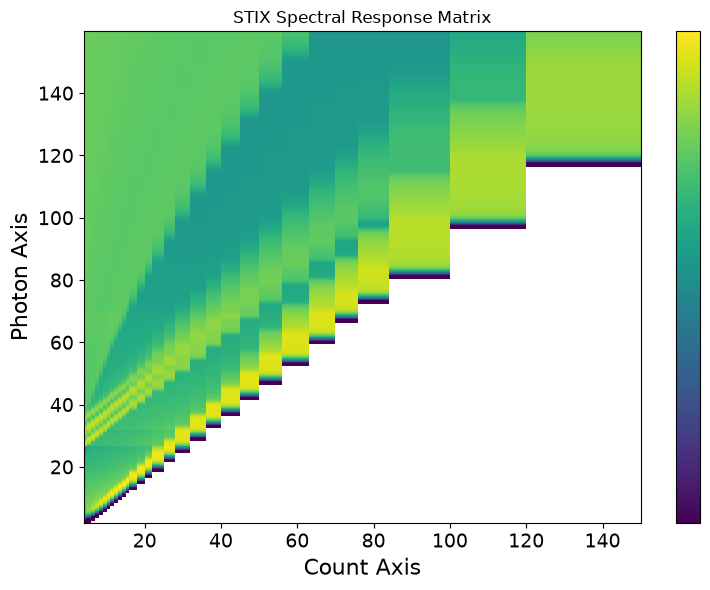

In [59]:
srm_plot = srm_dat['srm']
ph_axis = srm_dat['ph_axis']
ct_axis = spectrum.spectral_axis.bin_edges.value

fig, ax = plt.subplots(figsize=(8, 6))

mesh = ax.pcolormesh(ct_axis, ph_axis, srm_plot, cmap="viridis", norm=LogNorm(vmin=1e-11, vmax=srm_plot.max()))

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_ticks([])
ax.set_xlabel("Count Axis")
ax.set_ylabel("Photon Axis")
ax.set_title("STIX Spectral Response Matrix")

plt.tight_layout()
plt.show()

In [15]:
model = (((ThermalEmission() + ThickTarget()) | Albedo()) * InverseSquareFluxScaling() ) | MatrixModel()

model.param_names

('temperature_0',
 'emission_measure_0',
 'mg_0',
 'al_0',
 'si_0',
 's_0',
 'ar_0',
 'ca_0',
 'fe_0',
 'p_1',
 'break_energy_1',
 'q_1',
 'low_e_cutoff_1',
 'high_e_cutoff_1',
 'total_eflux_1',
 'theta_2',
 'anisotropy_2',
 'observer_distance_3',
 'conversion_factor_4')

In [20]:
model.break_energy_1 =1500*u.keV
model.break_energy_1.fixed = True
model.total_eflux_1.fixed = False
model.low_e_cutoff_1.min=8*u.keV
model.low_e_cutoff_1.max=60*u.keV

In [21]:
fitter = Fitter(model=model,
                spectrum_object=spectrum)

In [22]:
fitter.fit_range = [4.5*u.keV, 85*u.keV]

In [23]:
fitter._spectrum_object.__dict__

{'_spectral_axis_index': 0,
 '_spectral_axis': <SpectralAxis [  4.5,   5.5,   6.5,   7.5,   8.5,   9.5,  10.5,  11.5,  12.5,  13.5,
     14.5,  15.5,  17. ,  19. ,  21. ,  23.5,  26.5,  30. ,  34. ,  38. ,
     42.5,  47.5,  53. ,  59.5,  66.5,  73. ,  80. ,  92. , 110. , 135. ] keV>,
 '_data': array([1.87940680e+04, 4.24137524e+04, 1.37484459e+05, 9.94586799e+04,
        5.83730671e+04, 3.53715427e+04, 2.44727750e+04, 1.71312870e+04,
        1.21454276e+04, 8.57814833e+03, 6.36081226e+03, 4.86248577e+03,
        6.91019909e+03, 4.73339635e+03, 3.39760017e+03, 3.96946793e+03,
        2.63509794e+03, 2.30810076e+03, 1.50984127e+03, 1.05682459e+03,
        1.06029680e+03, 7.67015841e+02, 7.02210279e+02, 6.48743198e+02,
        4.73002476e+02, 2.11612478e+02, 1.69338954e+02, 2.08140725e+02,
        1.43691185e+02, 1.08581953e+02]),
 '_mask': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        

In [24]:
fitter._spectrum_object.meta['distance']
fitter._spectrum_object.meta['angle']

<Quantity 53.19306156 deg>

In [25]:
fitter.model.fixed

{'temperature_0': False, 'emission_measure_0': False, 'mg_0': True, 'al_0': True, 'si_0': True, 's_0': True, 'ar_0': True, 'ca_0': True, 'fe_0': True, 'p_1': False, 'break_energy_1': True, 'q_1': True, 'low_e_cutoff_1': False, 'high_e_cutoff_1': True, 'total_eflux_1': False, 'theta_2': False, 'anisotropy_2': True, 'observer_distance_3': True, 'conversion_factor_4': True}

In [26]:
fitter.do_fit()

/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/sunkit_spex/models/physical/thermal.py:1273: UserWarning: Some input energy values outside valid range of 1.0002920302956426--10.34753795157738 keV. Flux will be zero outside this range.
  warnings.warn(message)
Files Downloaded: 100%|██████████| 1/1 [00:03<00:00,  3.59s/file]


In [27]:
print(fitter.fitted_model)

Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: ([0] + [1] | [2]) * [3] | [4]
Components: 
    [0]: <ThermalEmission(temperature=20.18098588 MK, emission_measure=0.24696015 1 / cm3, mg=8.15, al=7.04, si=8.1, s=7.27, ar=6.58, ca=6.93, fe=8.1, name='ThermalEmission')>

    [1]: <ThickTarget(p=3.84721453, break_energy=1500. keV, q=5., low_e_cutoff=17.4370789 keV, high_e_cutoff=1500. keV, total_eflux=4.8310321 electron / s, name='ThickTarget')>

    [2]: <Albedo(theta=53.19306156 deg, anisotropy=1., name='Albedo')>

    [3]: <InverseSquareFluxScaling(observer_distance=0.5605425 AU, name='InverseSquareFluxScaling')>

    [4]: <MatrixModel(conversion_factor=1., name='SRM')>
Parameters:
      temperature_0     emission_measure_0 ... conversion_factor_4
            MK               1 / cm3       ...                    
    ------------------ ------------------- ... -------------------
    20.180985880980206 0.24696014709078937 ...                 1.0


/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/sunkit_spex/models/physical/thermal.py:1273: UserWarning: Some input energy values outside valid range of 1.0002920302956426--10.34753795157738 keV. Flux will be zero outside this range.
  warnings.warn(message)


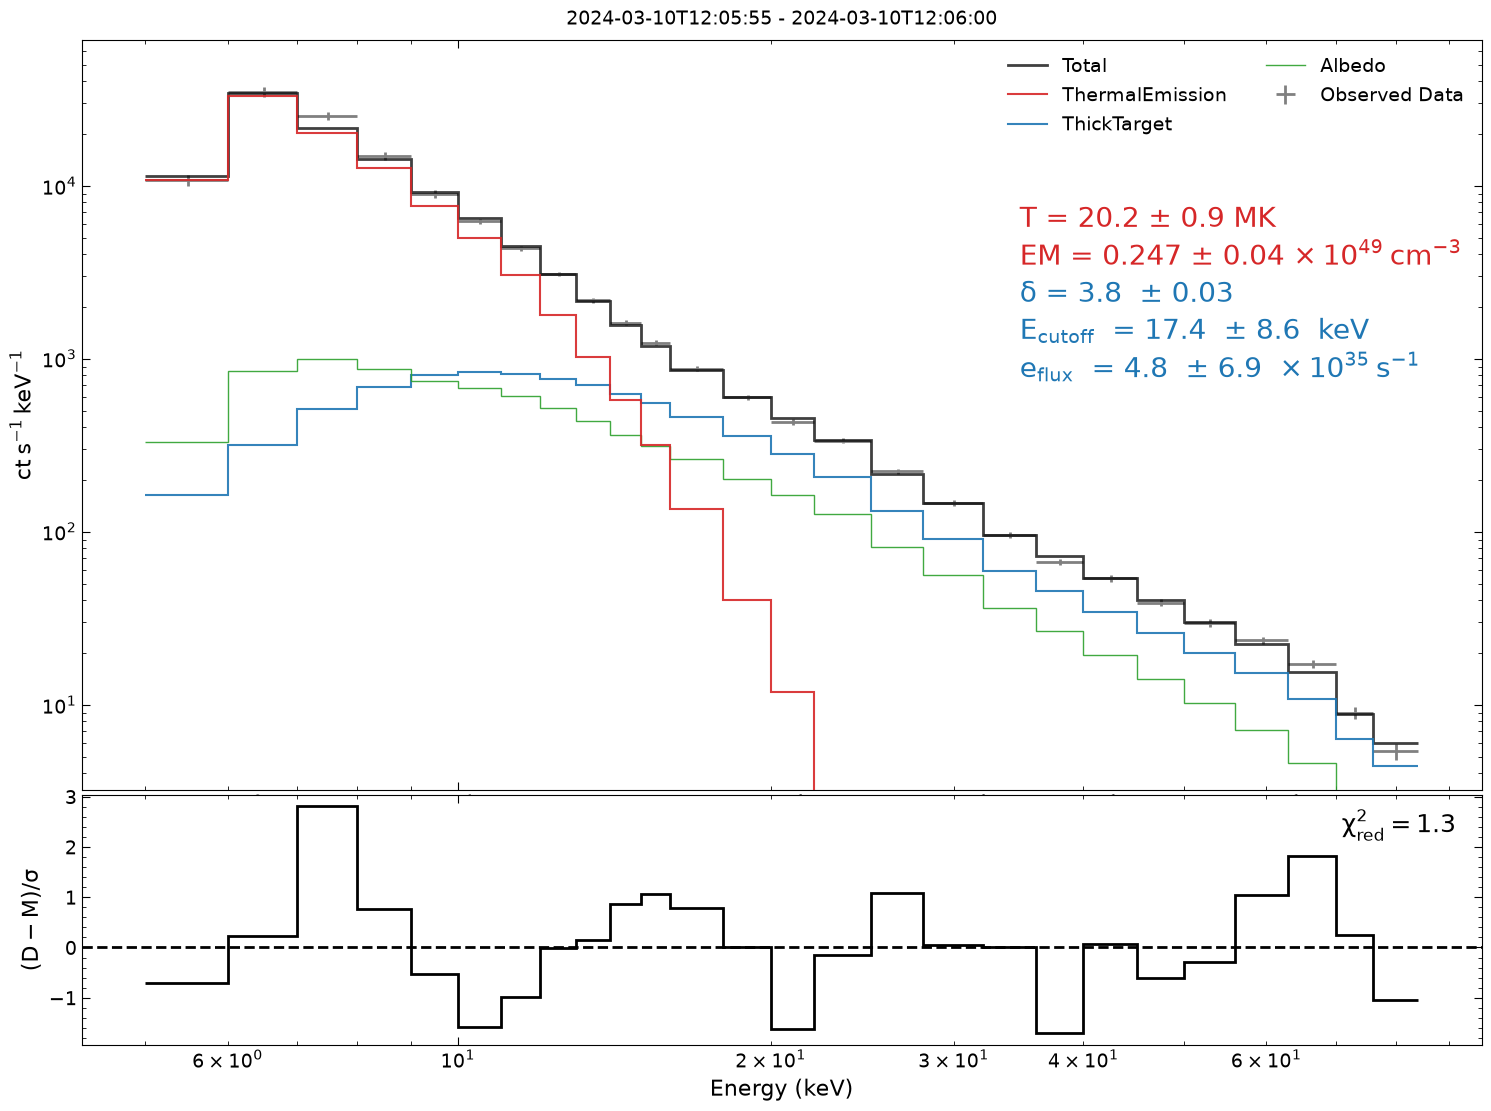

In [28]:
fitter.plot_fit_results()